# **3. Classification of natural disaster Tweets: Training**

The dataset used in this project comes from the Disaster Tweets dataset, which contains a collection of tweets labeled according to whether they refer to a real disaster event or not. The goal of the dataset is to support the development of machine learning models capable of automatically identifying disaster-related information from social media posts.

In natural language processing tasks, raw text data often contains noise such as punctuation, links, mentions, and other elements that may not contribute meaningful information for machine learning models. Therefore, applying different **text preprocessing strategies** can help improve model performance by standardizing and simplifying the textual input.

In this project, three different preprocessing configurations were implemented and compared to evaluate their impact on the classification performance.



## 0. Imports

In [57]:
import sys
!{sys.executable} -m pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import re
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import time
import json
from IPython.display import display, HTML
from datetime import datetime
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display
import pickle


## 1. Load dataset

In [126]:
path = 'Cleaned_Data/cleaned_data_conf.csv'


In [127]:
df1 = pd.read_csv(path)
df2 = pd.read_csv(path)


In [128]:
df1.isnull().sum()

text      0
target    0
dtype: int64

## 2. Preprocessing Data

In [129]:
y1 = df1['target']
x1 = df1.drop('target', axis=1)

vectorizer1 = TfidfVectorizer()
x1 = vectorizer1.fit_transform(x1['text'])
y1 = y1.to_numpy()
x1 = x1.toarray()


In [130]:
with open("vectorizer1.pkl", "wb") as f:
    pickle.dump(vectorizer1, f)

## 2. Divide Data

In [131]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
x1_val, x1_test, y1_val, y1_test = train_test_split(x1_test, y1_test, test_size=0.5, random_state=42)

print(f"Configuration 1: Train set: {(x1_train).shape}, Validation set: {(x1_val).shape}, Test set: {(x1_test).shape}")

Configuration 1: Train set: (5850, 14310), Validation set: (731, 14310), Test set: (732, 14310)


**Auxiliar functions**

In [133]:
def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    return acc, prec, rec, f1


def html_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = tf.keras.metrics.AUC()(y_true, y_pred).numpy()

    display(HTML(f"""
    <div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
    </div>
    """))
    return acc, prec, rec, f1, auc


def confusion_matrix_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Not Disaster", "Disaster"],
            yticklabels=["Not Disaster", "Disaster"])

    plt.title("Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [134]:
def metrics_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report.style.background_gradient(cmap="RdPu")


In [135]:
def save_metrics(model_name, configuration, acc, prec, rec, f1, auc):
    save_dir_path = "model_metrics"
    
    metrics_dict = {"model": model_name,
        "configuration": configuration,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    if not os.path.exists(save_dir_path):
        os.makedirs(save_dir_path, exist_ok=True)
    file_path = os.path.join(save_dir_path, f"{model_name}_{configuration}.json")
    with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
    print(f"Metrics saved to: {file_path}")

## **Configuration 1 – Neural network**

The first model configuration consists of a feedforward neural network. This approach represents a basic deep learning baseline that learns patterns directly from vectorized textual data.



In [136]:
model1 = models.Sequential()

model1.add(layers.Dense(128, activation='relu', input_shape=(x1_train.shape[1],)))
model1.add(layers.Dropout(0.5))

model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dropout(0.3))

model1.add(layers.Dense(32, activation='relu'))
model1.add(layers.Dense(16, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

c:\Users\Ale\Documents\NLP-Lab01\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [137]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision']
)

In [138]:
history1 = model1.fit(
    x1_train,
    y1_train,
    epochs=10,
    batch_size=32,
    validation_data=(x1_val, y1_val))

Epoch 1/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - Precision: 0.6923 - accuracy: 0.5779 - loss: 0.6762 - val_Precision: 1.0000 - val_accuracy: 0.5814 - val_loss: 0.6600
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.7124 - accuracy: 0.7326 - loss: 0.5467 - val_Precision: 0.5733 - val_accuracy: 0.6238 - val_loss: 0.6992
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.8259 - accuracy: 0.8581 - loss: 0.3539 - val_Precision: 0.5374 - val_accuracy: 0.6074 - val_loss: 0.8521
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.8951 - accuracy: 0.9104 - loss: 0.2494 - val_Precision: 0.5118 - val_accuracy: 0.5882 - val_loss: 0.9405
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.9122 - accuracy: 0.9268 - loss: 0.1894 - val_Precision: 0.5127 - val_accuracy: 0.5882 - val_loss: 1.0507
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.9310 - accuracy: 0.9398 - loss: 0.1514 - val_Precision: 0.5158 - val_accu

In [139]:
y1_pred = model1.predict(x1_test)
y1_pred = (y1_pred > 0.5).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [140]:
metrics(y1_test, y1_pred)

Accuracy: 0.5683060109289617
Precision: 0.5104166666666666
Recall: 0.45652173913043476
F1 Score: 0.4819672131147541

Confusion Matrix:
[[269 141]
 [175 147]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.66      0.63       410
           1       0.51      0.46      0.48       322

    accuracy                           0.57       732
   macro avg       0.56      0.56      0.56       732
weighted avg       0.56      0.57      0.56       732



(0.5683060109289617,
 0.5104166666666666,
 0.45652173913043476,
 0.4819672131147541)

,precision,recall,f1-score,support
0,0.605856,0.656098,0.629977,410.000000
1,0.510417,0.456522,0.481967,322.000000
accuracy,0.568306,0.568306,0.568306,0.568306
macro avg,0.558136,0.556310,0.555972,732.000000
weighted avg,0.563873,0.568306,0.564869,732.000000


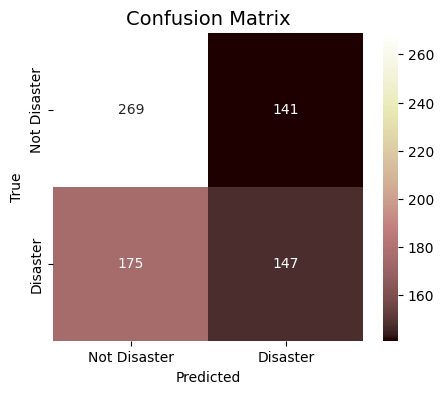

Metrics saved to: model_metrics\NN_NN.json


In [151]:
display(metrics_report(y1_test, y1_pred))
acc, prec, rec, f1, auc = html_metrics(y1_test, y1_pred)
confusion_matrix_heatmap(y1_test, y1_pred)
save_metrics("NN", "NN", acc, prec, rec, f1, auc)

## **Configuration 2 – LSTM Training Pipeline**





In [142]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [143]:
y2 = df2['target']
x2 = df2['text']

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)
x2_val, x2_test, y2_val, y2_test = train_test_split(x2_test, y2_test, test_size=0.5, random_state=42)

In [144]:
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(x2_train)

In [145]:
X_train_seq = tokenizer.texts_to_sequences(x2_train)
X_val_seq = tokenizer.texts_to_sequences(x2_val)
X_test_seq = tokenizer.texts_to_sequences(x2_test)

In [146]:
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

model2 = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.fit(
    X_train_pad,
    y2_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y2_val)
)

model2.evaluate(X_test_pad, y2_test)

Epoch 1/10


c:\Users\Ale\Documents\NLP-Lab01\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5968 - loss: 0.6673 - val_accuracy: 0.6211 - val_loss: 0.6676
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7848 - loss: 0.4734 - val_accuracy: 0.5896 - val_loss: 0.7450
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8805 - loss: 0.2874 - val_accuracy: 0.5814 - val_loss: 0.9372
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9209 - loss: 0.2042 - val_accuracy: 0.5759 - val_loss: 1.0789
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9390 - loss: 0.1529 - val_accuracy: 0.5595 - val_loss: 1.2119
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9460 - loss: 0.1215 - val_accuracy: 0.5705 - val_loss: 1.3304
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9491 - loss: 0.0996 - val_accuracy: 0.5390 - val_loss: 1.5253
Epoch 8/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9556 - loss: 0.0843 - val_accuracy: 0.566

[1.9273899793624878, 0.5778688788414001]

In [147]:
y2_pred = model2.predict(X_test_pad)

y2_pred = (y2_pred > 0.5).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [150]:
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       0.62      0.64      0.63       410
           1       0.52      0.50      0.51       322

    accuracy                           0.58       732
   macro avg       0.57      0.57      0.57       732
weighted avg       0.58      0.58      0.58       732



,precision,recall,f1-score,support
0,0.619385,0.639024,0.629052,410.000000
1,0.521036,0.500000,0.510301,322.000000
accuracy,0.577869,0.577869,0.577869,0.577869
macro avg,0.570210,0.569512,0.569676,732.000000
weighted avg,0.576122,0.577869,0.576814,732.000000


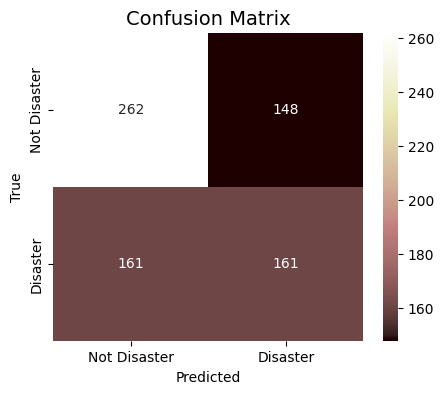

Metrics saved to: model_metrics\NN_LSTM.json


In [152]:

display(metrics_report(y2_test, y2_pred))
acc2, prec2, rec2, f12, auc2 = html_metrics(y2_test, y2_pred)
confusion_matrix_heatmap(y2_test, y2_pred)
save_metrics("NN", "LSTM", acc2, prec2, rec2, f12, auc2)